Saving 2026-04-17 10.12.56 AM.jpg to 2026-04-17 10.12.56 AM (1).jpg
🍚 Number of rice grains detected: 99


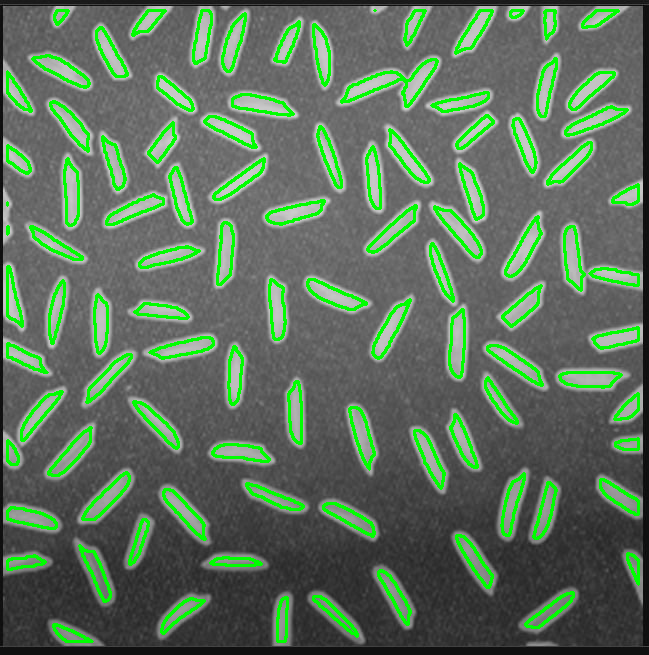

In [2]:
import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow
from scipy import ndimage as ndi

uploaded = files.upload()
filename = list(uploaded.keys())[0]
img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

#CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_eq = clahe.apply(img)

#Otsu threshold
_, thresh = cv2.threshold(img_eq, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

#Clean noise
kernel = np.ones((3,3), np.uint8)
cleaned = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

#Watershed
dist = cv2.distanceTransform(cleaned, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist, 0.4 * dist.max(), 255, 0)
sure_fg = np.uint8(sure_fg)


num_labels, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[cleaned == 0] = 0

img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
markers = cv2.watershed(img_color, markers)

rice_count = num_labels - 1  # subtract background
print(f"Number of rice grains detected: {rice_count}")


result = img_color.copy()
for label in range(2, num_labels + 1):
    mask = np.uint8(markers == label)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        cv2.drawContours(result, contours, -1, (0, 255, 0), 2)

cv2_imshow(result)